In [2]:
import matplotlib.pyplot as plt

# Import custom modules
# Add parent directory to path for myPkg imports
import sys
from pathlib import Path

# For notebooks, use current working directory to find parent
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))
    
from myPkg.optimization_utils import OptimizationMonitor
from myPkg.plotting_helpers import plot_fidelity_vs_parameter, plot_optimization_convergence, plot_parameter_vs_parameter, plt_config, plotting_styles
from myPkg.utils import *

---
### Optimized Parameters Case 1 : $T = 0.27$ μs $\&$ $\tau/T = 0.175$

In this analysis, we investigate how the optimized pulse amplitudes $\Omega_r$ and $\Delta_r$ vary with the Rydberg blockade strength $B$ under fixed temporal parameters:

- Gate time: $T = 0.27$ μs (fixed)
- Pulse shape parameter: $\tau/T = 0.175$ (fixed)

By fixing the temporal structure of the adiabatic rapid passage (ARP) pulse, we focus exclusively on how the optimal Rabi frequency $\Omega_r$ and detuning $\Delta_r$ must adapt to different interaction strengths $B$ to maintain high gate fidelity.

In [41]:
summary_paths = ['save_data/CZ_gate_ARP_RydbergB_T0.27us_combined_summary/summary027us_branch01.csv', 'save_data/CZ_gate_ARP_RydbergB_T0.27us_combined_summary/summary027us_branch02.csv']
dfList = []
for summary_path in summary_paths:
  dfList.append(pd.read_csv(summary_path))

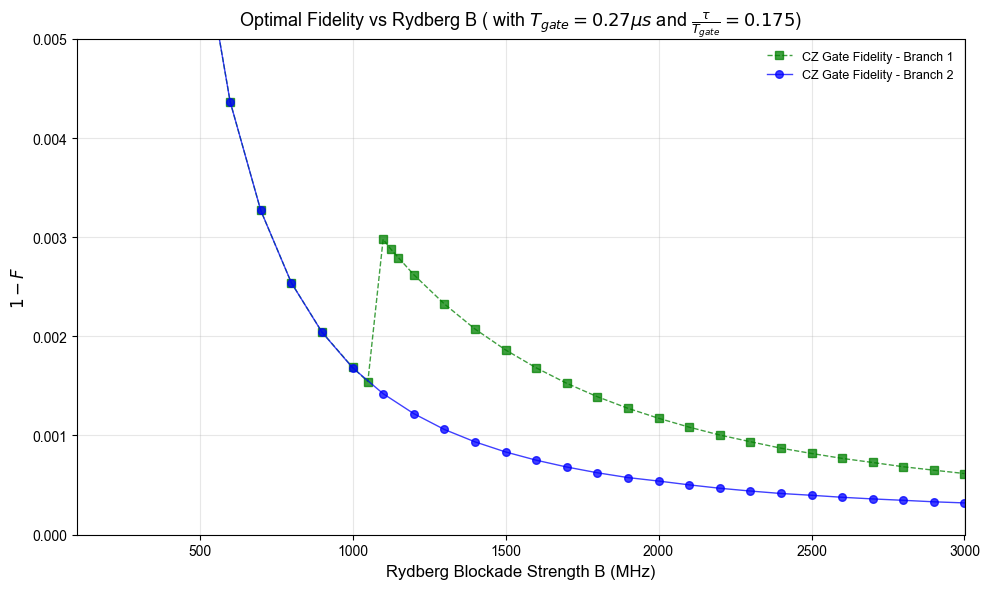

In [42]:
# Apply plotting configuration
plt.rcParams.update(plt_config)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

plotstyleList = [plotting_styles['fidelity_style_a'], plotting_styles['fidelity_style_b']]
plotstyleList[0]["markersize"] = 5.5
plotstyleList[1]["markersize"] = 5.5
# Plot fidelity vs B using plotting_helpers function
for i, df in enumerate(dfList):
    legend_label = f'CZ Gate Fidelity - Branch {i+1}'
    plot_fidelity_vs_parameter(
        ax=ax,
        param_list=df['Rydberg_B_MHz'].values,
        fidelity_list=[df['fidelity'].values],
        legend_list=[legend_label],
        title=r'Optimal Fidelity vs Rydberg B ( with $T_{gate} = 0.27 \mu s$ and $\frac{\tau}{T_{gate}} = 0.175$)',
        xlabel='Rydberg Blockade Strength B (MHz)',
        ylabel='Fidelity',
        use_infidelity=True,
        log_scale=False,
        ylim=[0, 0.005],
        grid_alpha=0.3,
        show_legend=True,
        plotting_style_list=[plotstyleList[i]]
    )

plt.tight_layout()
plt.show()

### 3. Plot Optimized Parameters vs B

In [46]:
# Parameter bounds
bounds = {
        'T_gate': (0.0, 1.2),
        'tau_ratio': (0.175, 0.175), # Fixed tau_ratio for ARP ( why? )
        'amp_Omega_r': (15*2*np.pi, 35*2*np.pi),
        'amp_Delta_r': (25*2*np.pi, 45*2*np.pi)
    }

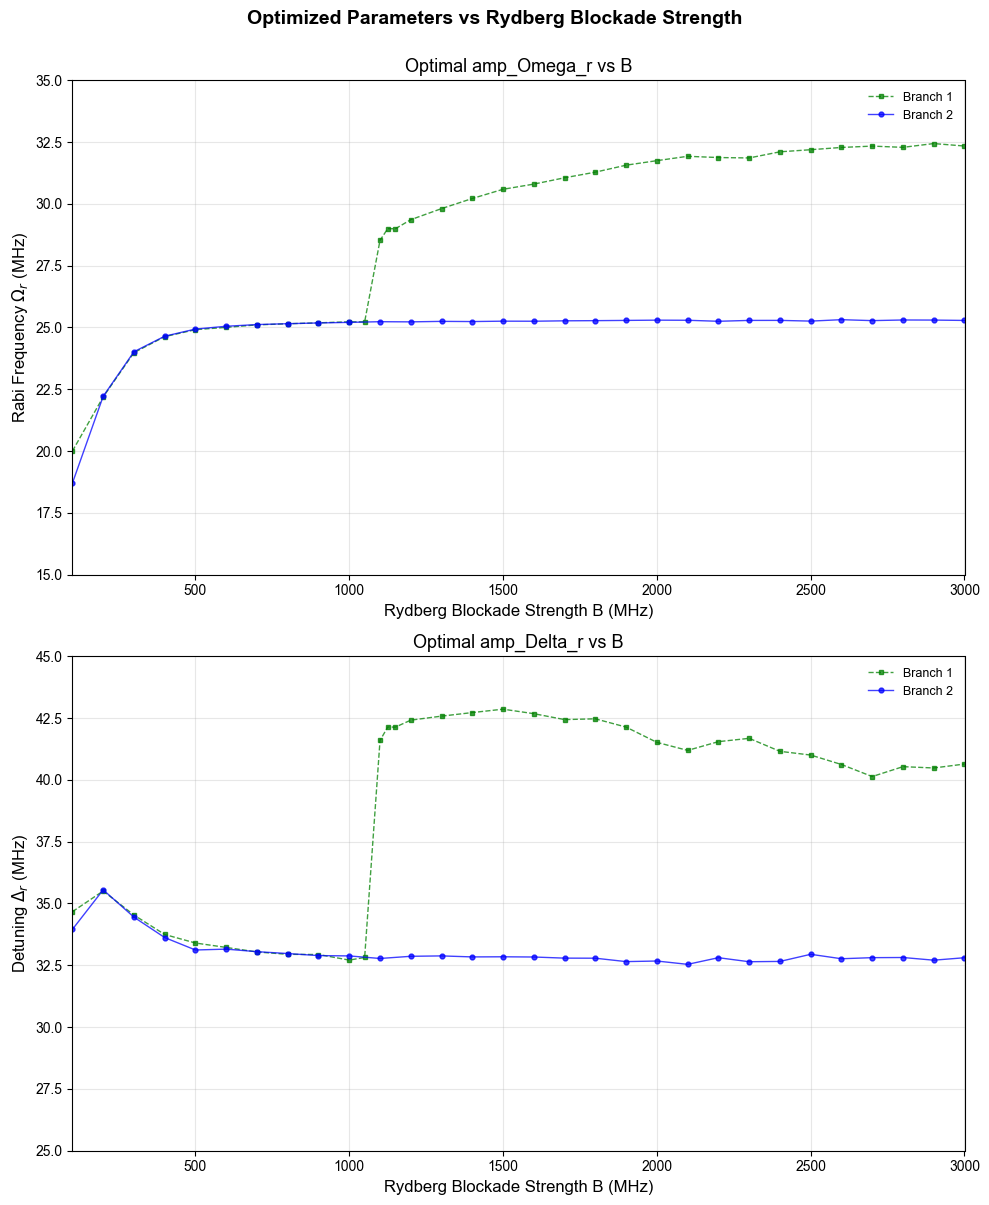

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Parameter information: (column_name, ylabel, need_conversion_to_MHz)
param_info = [
    ('amp_Omega_r', r'Rabi Frequency $\Omega_r$ (MHz)', True, axes[0]),
    ('amp_Delta_r', r'Detuning $\Delta_r$ (MHz)', True, axes[1])
]

plotstyleList[0]["markersize"] = 3.5
plotstyleList[1]["markersize"] = 3.5
for param_name, ylabel, convert_to_MHz, ax in param_info:
    if param_name == 'T_gate':
        continue
    if param_name == 'tau_ratio':
        continue
    # Convert to appropriate units
    if convert_to_MHz:
        # Convert from rad/μs to MHz
        param_values = df[param_name].values / (2 * np.pi)
    else:
        param_values = df[param_name].values
    
    # Use plot_parameter_vs_parameter function
    for i, df in enumerate(dfList):
        legend_label = f'Branch {i+1}'
        plot_parameter_vs_parameter(
            ax=ax,
            x_param_list=df['Rydberg_B_MHz'].values,
            y_param_list=[df[param_name].values / (2 * np.pi) if convert_to_MHz else df[param_name].values],
            legend_list=[legend_label],
            title=f'Optimal {param_name} vs B',
            xlabel='Rydberg Blockade Strength B (MHz)',
            ylabel=ylabel,
            show_legend=True if i==len(dfList)-1 else False,
            grid_alpha=0.3,
            ylim = bounds[param_name] if not convert_to_MHz else (bounds[param_name][0]/(2*np.pi), bounds[param_name][1]/(2*np.pi)),
            plotting_style_list=[plotstyleList[i]]
        )
    
    # Mark best fidelity point
    # ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], best_val, 
    #         'r*', markersize=15, label='Best Fidelity', zorder=5)

plt.suptitle('Optimized Parameters vs Rydberg Blockade Strength', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Observations: Parameter and Infidelity Behavior vs Rydberg Blockade Strength

**Infidelity trend:**
- For B < 1100 MHz: 

  Infidelity decreases as B increases.
- At B ≈ 1100-1150 MHz: 
  
  A sharp **discontinuous jump** in infidelity occurs, which indicates a transition.
- For B > 1150 MHz: 

  Infidelity also decreases as B increases, and shows a trend to saturation.

**Optimized pulse amplitudes ($\Omega_r$ and $\Delta_r$) trend:**
- For B < 1100 MHz: Both $\Omega_r$ and $\Delta_r$ show smooth, gradual variation, , and shows a trend to saturation until at B = 1100 MHz it mets a sudden change.
- At B ≈ 1100-1150 MHz: Both parameters exhibit an **abrupt jump** 
- For B > 1150 MHz: The parameters settle to different values and continue varying smoothly, and shows a trend to saturation.

The transitions in optimized pulse amplitudes **coincide** with the infidelity jump at the same B range.

---
### Optimized Parameters Study Case 2 : $T = 0.54$ μs $\&$ $\tau/T = 0.175$

In this analysis, we investigate how the optimized pulse amplitudes $\Omega_r$ and $\Delta_r$ vary with the Rydberg blockade strength $B$ under fixed temporal parameters:

- Gate time: $T = 0.54$ μs (fixed)
- Pulse shape parameter: $\tau/T = 0.175$ (fixed)

The only difference with case 1 is the fixed value of Gate time $T$

In [32]:
summary_path = 'save_data/CZ_gate_ARP_RydbergB_T0.54us_combined_summary/summary054us_branch01.csv'
df = pd.read_csv(summary_path)

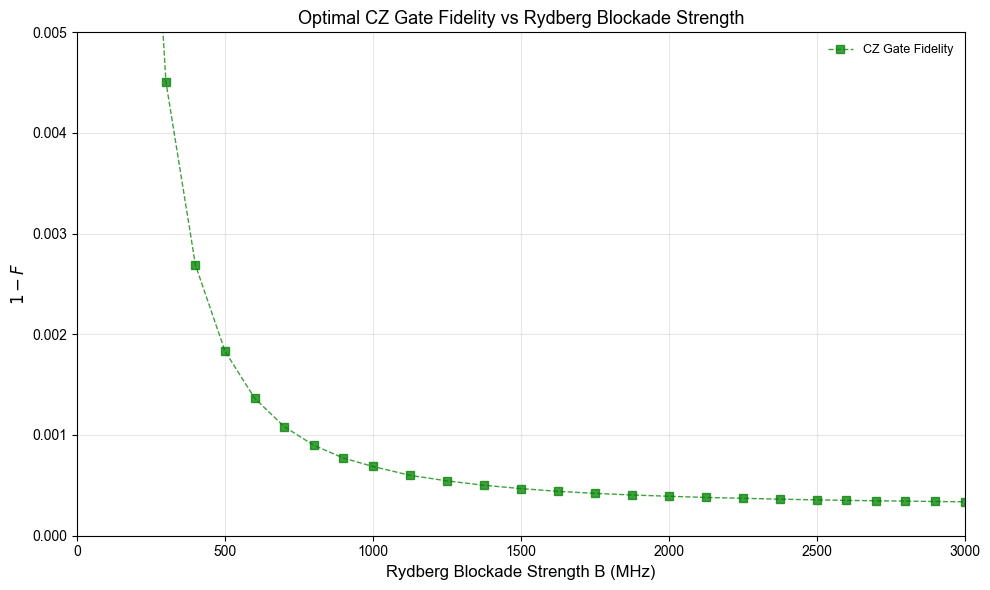


🏆 Best Fidelity Result:
  B = 3000 MHz
  Fidelity = 0.999664
  Infidelity = 3.36e-04


In [35]:
# Apply plotting configuration
plt.rcParams.update(plt_config)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

plotstyleList = [plotting_styles['fidelity_style_a']]
plotstyleList[0]["markersize"] = 5.5

# Plot fidelity vs B using plotting_helpers function
plot_fidelity_vs_parameter(
    ax=ax,
    param_list=df['Rydberg_B_MHz'].values,
    fidelity_list=[df['fidelity'].values],
    legend_list=['CZ Gate Fidelity'],
    title='Optimal CZ Gate Fidelity vs Rydberg Blockade Strength',
    xlabel='Rydberg Blockade Strength B (MHz)',
    ylabel='Fidelity',
    use_infidelity=True,
    log_scale=False,
    xlim=[0,3000],
    ylim=[0, 0.005],
    grid_alpha=0.3,
    show_legend=True,
    plotting_style_list=plotstyleList
)

# Mark the best fidelity point
best_idx = df['fidelity'].idxmax()
# ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], 1 - df.loc[best_idx, 'fidelity'], 
#         'r*', markersize=15, label=f"Best: F={df.loc[best_idx, 'fidelity']:.6f}")
# ax.legend()

plt.tight_layout()
plt.show()

# Print best result
print(f"\n🏆 Best Fidelity Result:")
print(f"  B = {df.loc[best_idx, 'Rydberg_B_MHz']:.0f} MHz")
print(f"  Fidelity = {df.loc[best_idx, 'fidelity']:.6f}")
print(f"  Infidelity = {1 - df.loc[best_idx, 'fidelity']:.2e}")

In [36]:
bounds = {
  'T_gate': (0.0, 1.2),
  'tau_ratio': (0.175, 0.175),
  'amp_Omega_r': (10*2*np.pi, 15*2*np.pi),
  'amp_Delta_r': (15*2*np.pi, 20*2*np.pi)
}

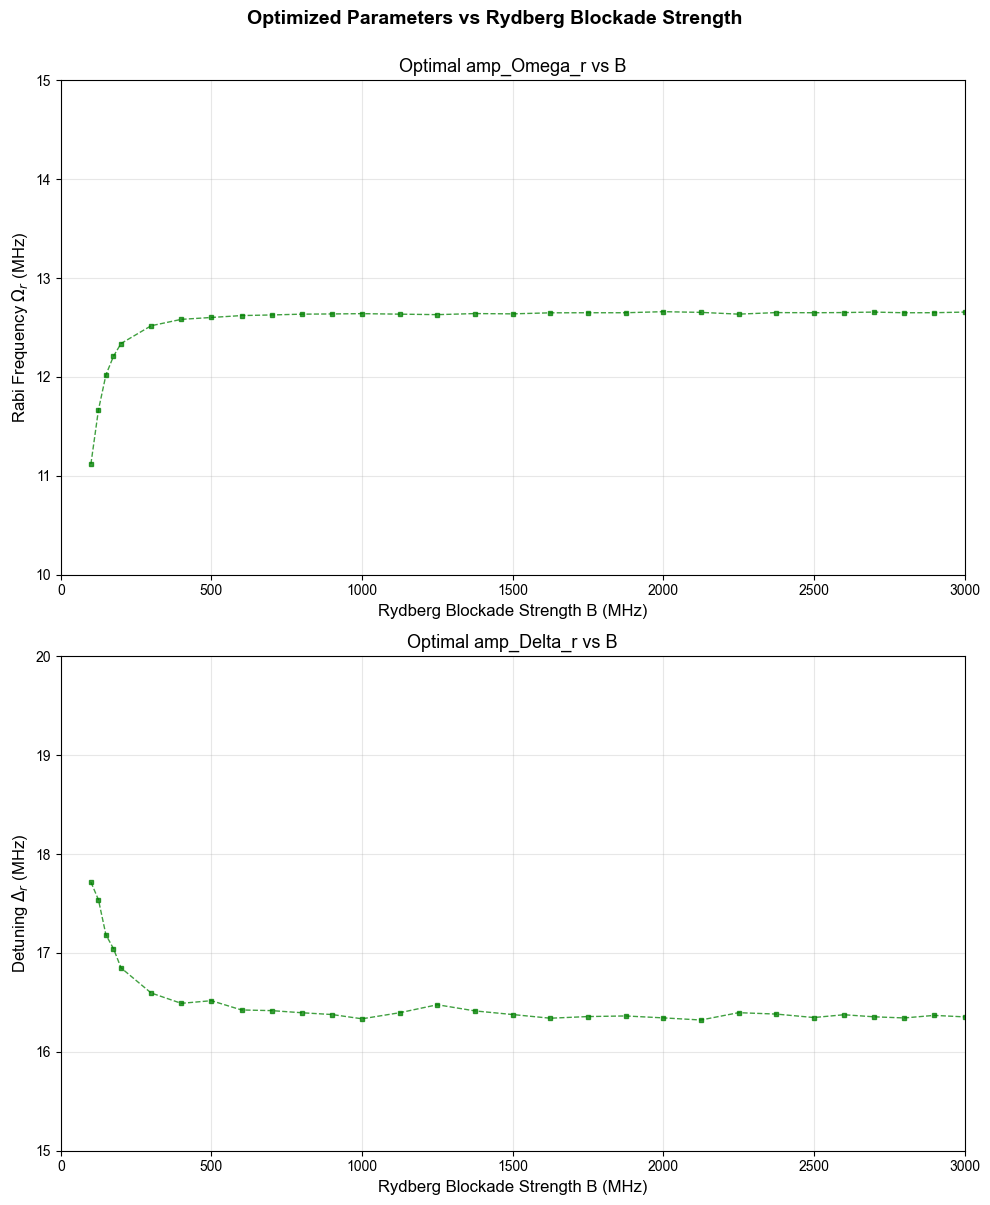

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Parameter information: (column_name, ylabel, need_conversion_to_MHz)
param_info = [
    ('amp_Omega_r', r'Rabi Frequency $\Omega_r$ (MHz)', True, axes[0]),
    ('amp_Delta_r', r'Detuning $\Delta_r$ (MHz)', True, axes[1])
]

plotstyleList[0]["markersize"] = 3.5
for param_name, ylabel, convert_to_MHz, ax in param_info:
    if param_name == 'T_gate':
        continue
    if param_name == 'tau_ratio':
        continue
    
    # Convert to appropriate units
    if convert_to_MHz:
        # Convert from rad/μs to MHz
        param_values = df[param_name].values / (2 * np.pi)
        best_val = df.loc[best_idx, param_name] / (2 * np.pi)
    else:
        param_values = df[param_name].values
        best_val = df.loc[best_idx, param_name]
    
    # Use plot_parameter_vs_parameter function
    plot_parameter_vs_parameter(
        ax=ax,
        x_param_list=df['Rydberg_B_MHz'].values,
        y_param_list=[param_values],
        legend_list=[param_name],
        title=f'Optimal {param_name} vs B',
        xlabel='Rydberg Blockade Strength B (MHz)',
        ylabel=ylabel,
        show_legend=False,
        grid_alpha=0.3,
        xlim=[0,3000],
        ylim = bounds[param_name] if not convert_to_MHz else (bounds[param_name][0]/(2*np.pi), bounds[param_name][1]/(2*np.pi)),
        plotting_style_list=plotstyleList
    )
    
    # Mark best fidelity point
    # ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], best_val, 
    #         'r*', markersize=15, label='Best Fidelity', zorder=5)

plt.suptitle('Optimized Parameters vs Rydberg Blockade Strength', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
### Optimized Parameters Study Case 3 : $T = 1.08$ μs $\&$ $\tau/T = 0.175$

In this analysis, we investigate how the optimized pulse amplitudes $\Omega_r$ and $\Delta_r$ vary with the Rydberg blockade strength $B$ under fixed temporal parameters:

- Gate time: $T = 1.08$ μs (fixed)
- Pulse shape parameter: $\tau/T = 0.175$ (fixed)

The only difference with case 1 is the fixed value of Gate time $T$

In [7]:
summary_paths = ['save_data/CZ_gate_ARP_RydbergB_T1.08us_combined_summary/summary108us_branch01.csv', 'save_data/CZ_gate_ARP_RydbergB_T1.08us_combined_summary/summary108us_branch02.csv']
dfList = []
for summary_path in summary_paths:
  dfList.append(pd.read_csv(summary_path))

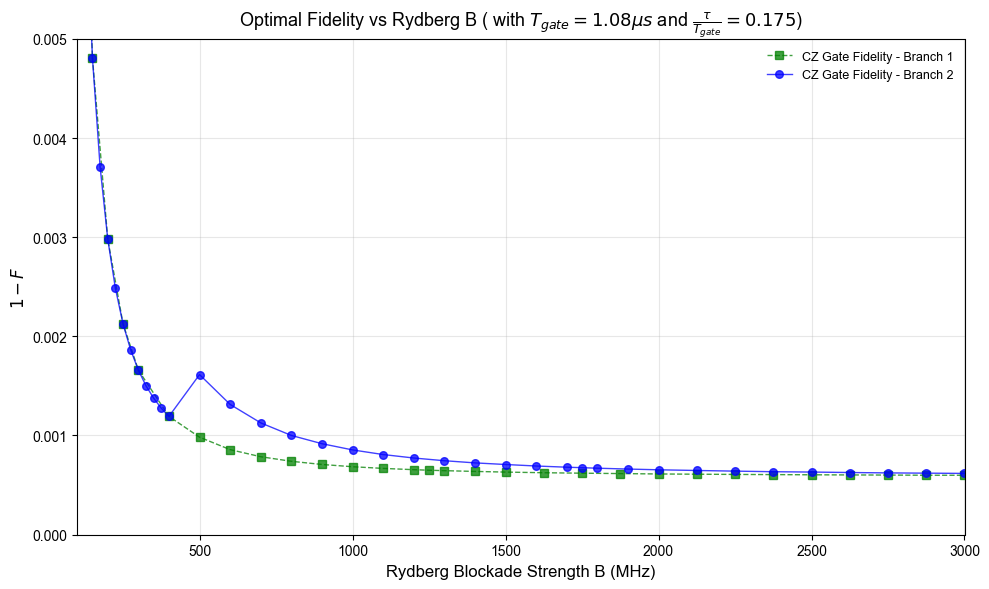

In [22]:
# Apply plotting configuration
plt.rcParams.update(plt_config)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

plotstyleList = [plotting_styles['fidelity_style_a'], plotting_styles['fidelity_style_b']]
plotstyleList[0]["markersize"] = 5.5
plotstyleList[1]["markersize"] = 5.5
# Plot fidelity vs B using plotting_helpers function
for i, df in enumerate(dfList):
    legend_label = f'CZ Gate Fidelity - Branch {i+1}'
    plot_fidelity_vs_parameter(
        ax=ax,
        param_list=df['Rydberg_B_MHz'].values,
        fidelity_list=[df['fidelity'].values],
        legend_list=[legend_label],
        title=r'Optimal Fidelity vs Rydberg B ( with $T_{gate} = 1.08 \mu s$ and $\frac{\tau}{T_{gate}} = 0.175$)',
        xlabel='Rydberg Blockade Strength B (MHz)',
        ylabel='Fidelity',
        use_infidelity=True,
        log_scale=False,
        ylim=[0, 0.005],
        grid_alpha=0.3,
        show_legend=True,
        plotting_style_list=[plotstyleList[i]]
    )

plt.tight_layout()
plt.show()

In [12]:
bounds = {
  'T_gate': (0.0, 1.2),
  'tau_ratio': (0.175, 0.175),
  'amp_Omega_r': (6.0*2*np.pi, 8.5*2*np.pi),
  'amp_Delta_r': (8.0*2*np.pi, 10.5*2*np.pi)
}

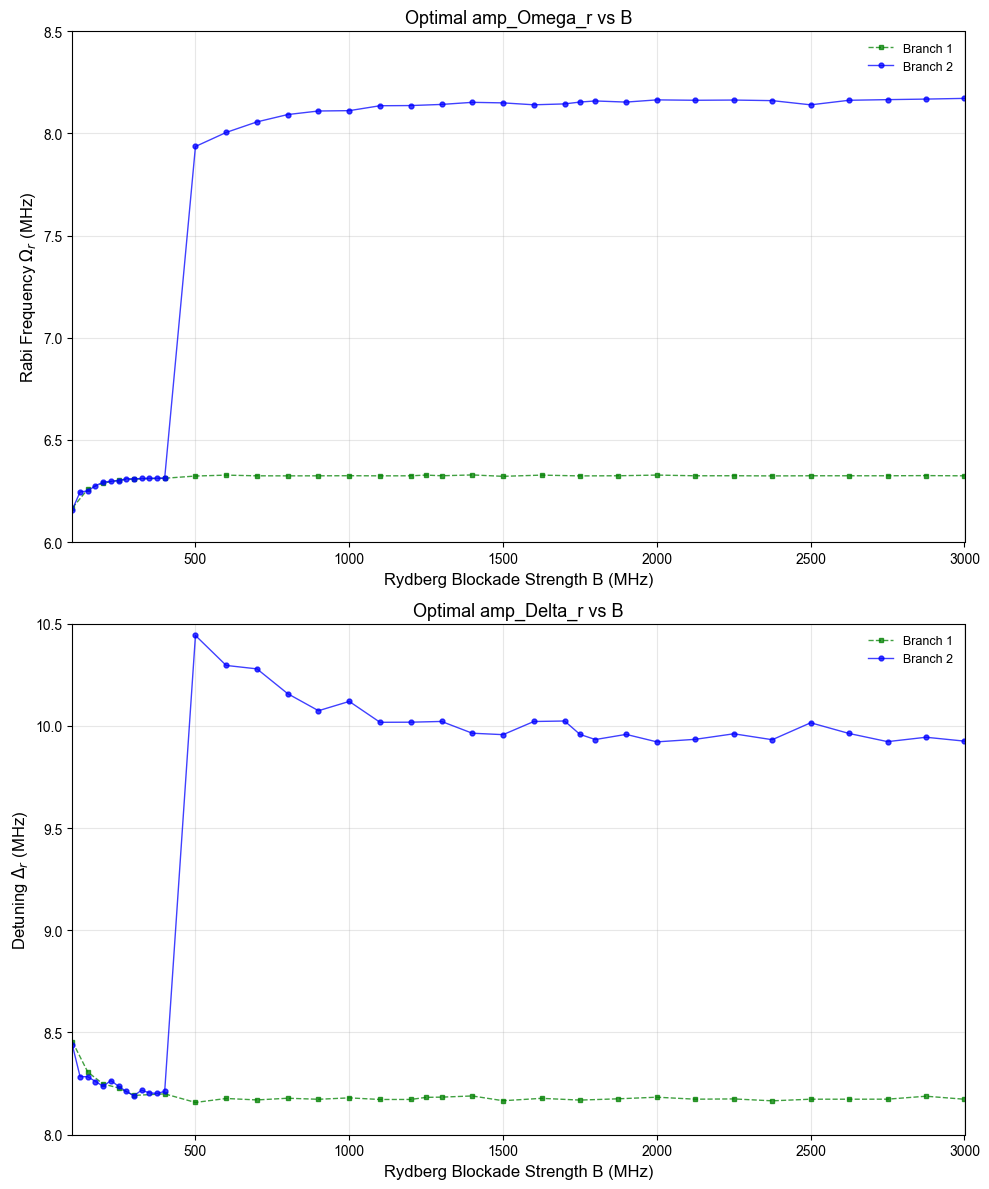

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Parameter information: (column_name, ylabel, need_conversion_to_MHz)
param_info = [
    ('amp_Omega_r', r'Rabi Frequency $\Omega_r$ (MHz)', True, axes[0]),
    ('amp_Delta_r', r'Detuning $\Delta_r$ (MHz)', True, axes[1])
]

plotstyleList[0]["markersize"] = 3.5
plotstyleList[1]["markersize"] = 3.5
for param_name, ylabel, convert_to_MHz, ax in param_info:
    if param_name == 'T_gate':
        continue
    if param_name == 'tau_ratio':
        continue

    # Convert to appropriate units
    if convert_to_MHz:
        # Convert from rad/μs to MHz
        param_values = df[param_name].values / (2 * np.pi)
    else:
        param_values = df[param_name].values
    
    # Use plot_parameter_vs_parameter function
    for i, df in enumerate(dfList):
        legend_label = f'Branch {i+1}'
        plot_parameter_vs_parameter(
            ax=ax,
            x_param_list=df['Rydberg_B_MHz'].values,
            y_param_list=[df[param_name].values / (2 * np.pi) if convert_to_MHz else df[param_name].values],
            legend_list=[legend_label],
            title=f'Optimal {param_name} vs B',
            xlabel='Rydberg Blockade Strength B (MHz)',
            ylabel=ylabel,
            show_legend=True if i==len(dfList)-1 else False,
            grid_alpha=0.3,
            ylim = bounds[param_name] if not convert_to_MHz else (bounds[param_name][0]/(2*np.pi), bounds[param_name][1]/(2*np.pi)),
            plotting_style_list=[plotstyleList[i]]
        )
    
    # Mark best fidelity point
    # ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], best_val, 
    #         'r*', markersize=15, label='Best Fidelity', zorder=5)

# plt.suptitle('Optimized Parameters vs Rydberg Blockade Strength', 
#              fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()